In [ ]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
# In Colab/Kaggle, these are pre-installed. In VS Code run:
# pip install pandas seaborn matplotlib in your terminal first.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

In [ ]:
# ============================================================
# CELL 2: Load the Iris Dataset
# ============================================================
# seaborn has the Iris dataset built-in — no file download needed!
# load_dataset() returns a pandas DataFrame directly.

df = sns.load_dataset('iris')

print("Dataset loaded!")
print(f"Shape: {df.shape}")          # (150, 5) → 150 rows, 5 columns
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
df.head()                             # In Jupyter, last line auto-displays as table

Dataset loaded!
Shape: (150, 5)

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# ============================================================
# CELL 3: Data Inspection
# ============================================================

# .info() tells you: column types, how many non-null values exist
# If a column has fewer non-null values than total rows → missing data
print("=== df.info() ===")
df.info()

print("\n=== df.describe() ===")
# .describe() gives: count, mean, std, min, 25%, 50%, 75%, max
# Only works on numeric columns — 'species' is text so it's excluded
df.describe()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== df.describe() ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# ============================================================
# CELL 4: Missing Values & Class Distribution
# ============================================================

print("Missing values per column:")
print(df.isnull().sum())
# All zeros = no missing data (Iris is a clean dataset)

print("\nSpecies distribution:")
print(df['species'].value_counts())
# Should show 50 of each: setosa, versicolor, virginica
# This is a "balanced" dataset — important in ML!

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


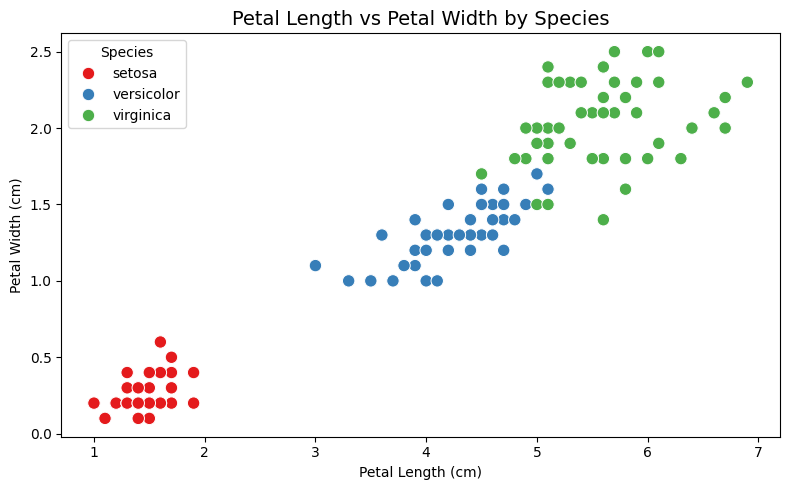

In [ ]:
# ============================================================
# CELL 5: Scatter Plot — Relationship between features
# ============================================================
# Question: Is there a pattern between petal_length & petal_width?
# Color each point by species to see if they cluster separately

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='petal_length',   # x-axis feature
    y='petal_width',    # y-axis feature
    hue='species',      # color by species
    palette='Set1',     # color scheme
    s=80                # dot size
)

plt.title('Petal Length vs Petal Width by Species', fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# WHAT YOU SHOULD SEE:
# Setosa (red) → small petals, clustered bottom-left
# Versicolor (blue) → medium petals, middle cluster
# Virginica (green) → large petals, top-right cluster
# This means petal size is a STRONG predictor of species!

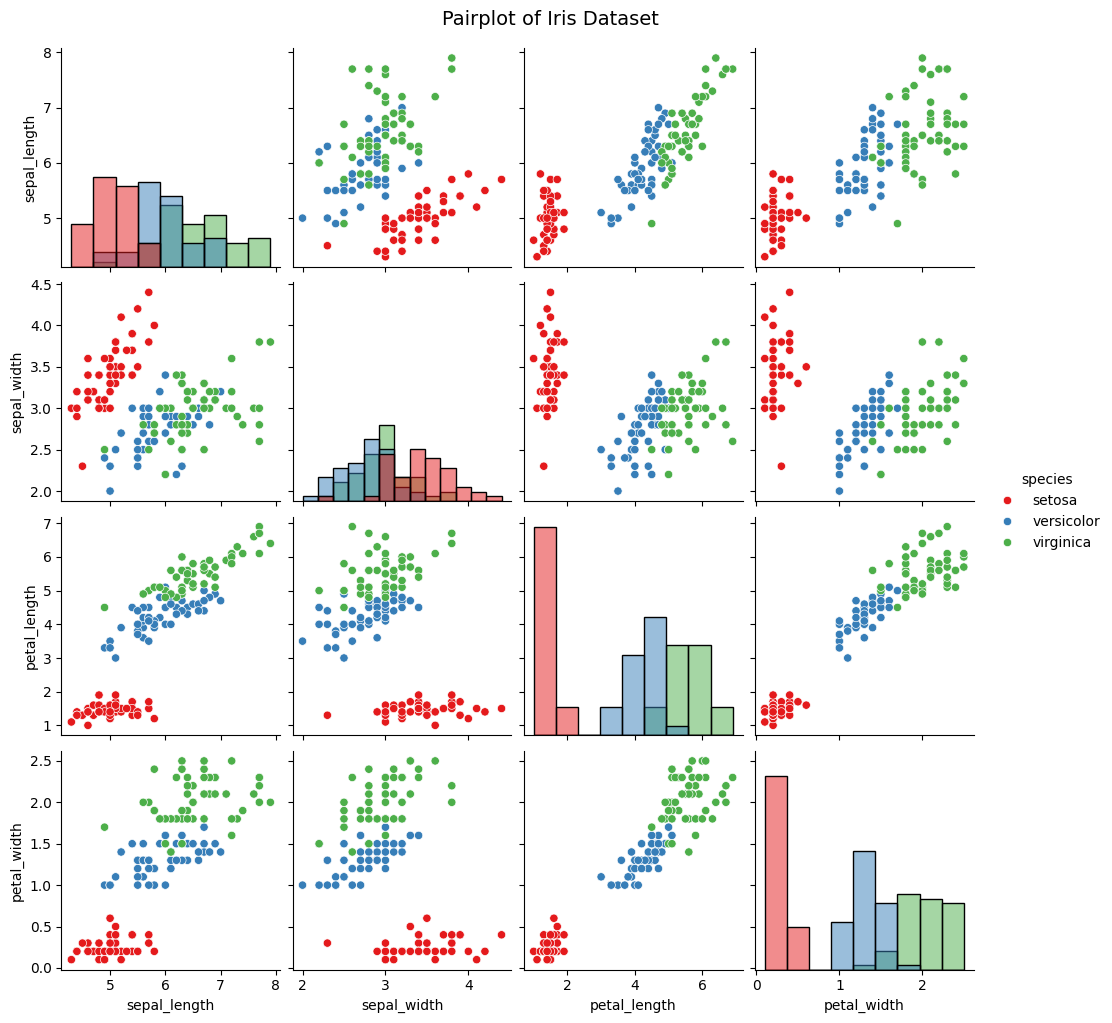

In [ ]:
# ============================================================
# CELL 6: Pairplot — All feature combinations at once
# ============================================================
# This is a grid of scatter plots: every feature vs every other feature
# Diagonal shows histograms for each feature

sns.pairplot(df, hue='species', palette='Set1', diag_kind='hist')
plt.suptitle('Pairplot of Iris Dataset', y=1.02, fontsize=14)
plt.show()

# WHAT TO LOOK FOR:
# When clusters are clearly separated → that feature pair is useful for ML
# When clusters overlap → those features alone won't separate species well

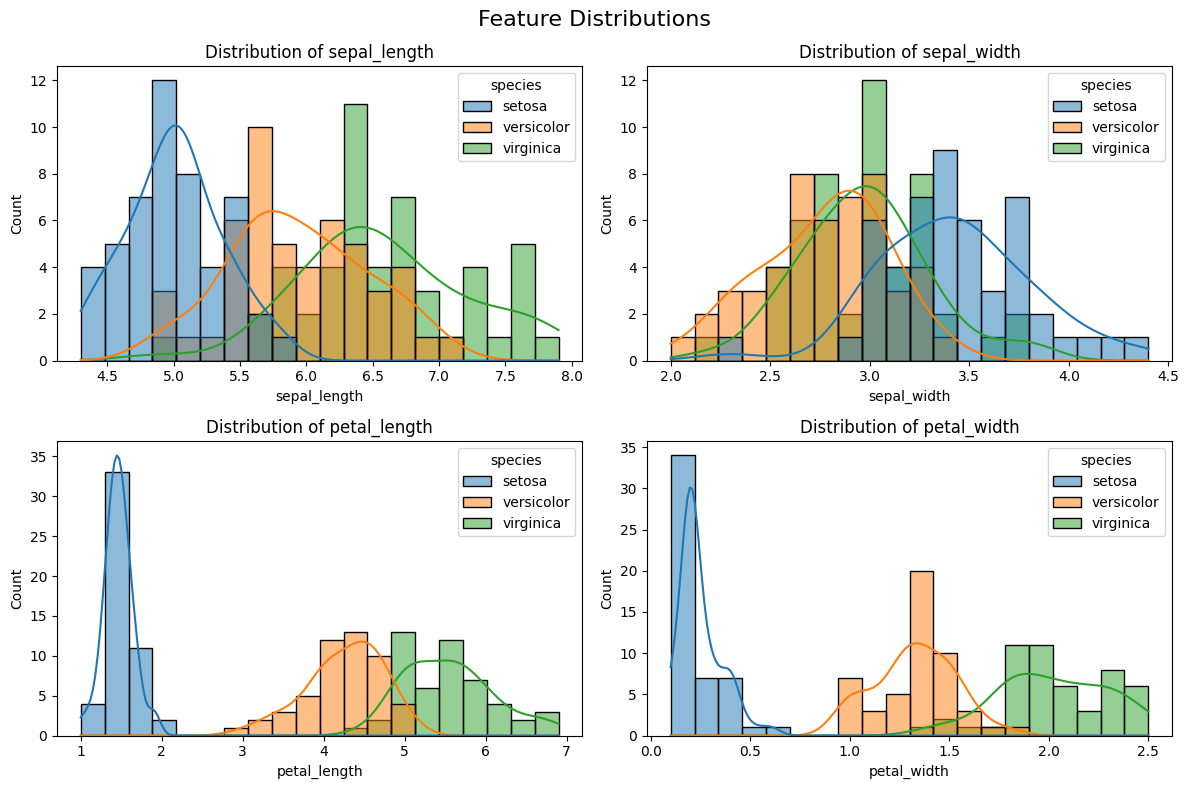

In [ ]:
# ============================================================
# CELL 7: Histograms — Distribution of each numeric feature
# ============================================================
# A histogram shows: how many values fall in each "bucket"
# Tall bar = many values in that range

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid of plots
fig.suptitle('Feature Distributions', fontsize=16)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row = i // 2      # 0,0,1,1
    col = i % 2       # 0,1,0,1

    sns.histplot(
        data=df,
        x=feature,
        hue='species',    # separate histogram per species, overlaid
        bins=20,          # number of bars
        kde=True,         # adds a smooth curve on top
        ax=axes[row][col]
    )
    axes[row][col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
# petal_length histogram → 3 separate bumps = 3 species clearly separated
# sepal_width histogram → bumps overlap = harder to separate species by this alone

/tmp/ipykernel_19538/2912625773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19538/2912625773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19538/2912625773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19538/2912625773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


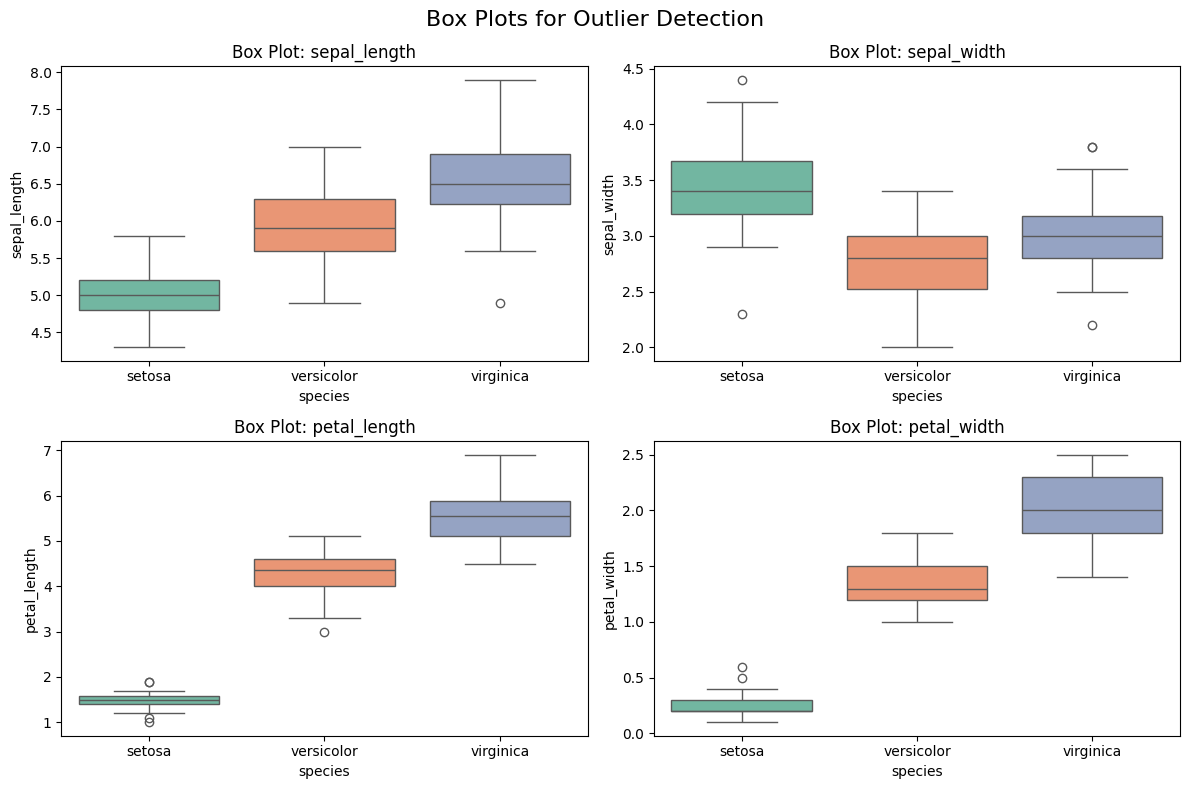

In [ ]:
# ============================================================
# CELL 8: Box Plots — Identify outliers per feature
# ============================================================
# Box plot shows: median (line), IQR box (25%-75%), whiskers, and DOTS = outliers

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Box Plots for Outlier Detection', fontsize=16)

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2

    sns.boxplot(
        data=df,
        x='species',    # one box per species
        y=feature,
        palette='Set2',
        ax=axes[row][col]
    )
    axes[row][col].set_title(f'Box Plot: {feature}')

plt.tight_layout()
plt.show()

# HOW TO READ A BOX PLOT:
# The box = middle 50% of data (IQR)
# Line inside box = median
# Whiskers = data range (excluding outliers)
# Dots beyond whiskers = OUTLIERS (unusual values)
# Iris has very few outliers — it's a clean dataset

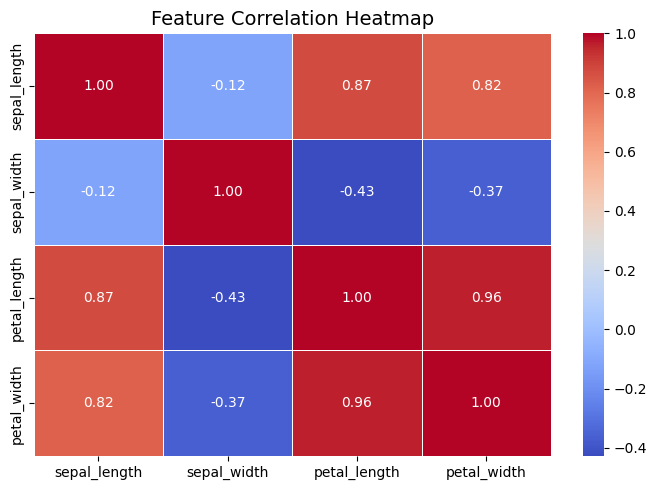

In [ ]:
# ============================================================
# CELL 9: Correlation Heatmap — Which features are related?
# ============================================================
# Correlation: +1 = perfectly related, -1 = opposite, 0 = no relation

plt.figure(figsize=(7, 5))

# Only numeric columns for correlation
numeric_df = df.drop('species', axis=1)

sns.heatmap(
    numeric_df.corr(),
    annot=True,        # show numbers inside boxes
    cmap='coolwarm',   # red = high correlation, blue = low
    fmt='.2f',         # 2 decimal places
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# WHAT YOU SHOULD SEE:
# petal_length & petal_width → 0.96 correlation (almost perfectly related!)
# sepal_length & sepal_width → low correlation
# High correlation between features = "multicollinearity" (important in ML later)

In [ ]:
readme_content = """# Task 1: Exploring and Visualizing the Iris Dataset

## Objective
Learn how to load, inspect, and visualize a dataset to understand
data trends, distributions, and relationships between features.

## Dataset
- **Name:** Iris Dataset
- **Source:** Built-in via Seaborn (`sns.load_dataset('iris')`)
- **Size:** 150 samples, 5 columns
- **Features:** sepal_length, sepal_width, petal_length, petal_width, species
- **Classes:** Setosa, Versicolor, Virginica (50 samples each)

## Tools & Libraries
- Python, Pandas, NumPy
- Matplotlib, Seaborn

## What Was Done
- Loaded and inspected dataset using `.head()`, `.info()`, `.describe()`
- Checked for missing values and class balance
- Created scatter plots to show feature relationships
- Created histograms to show value distributions per species
- Created box plots to identify outliers
- Created a pairplot showing all feature combinations
- Created a correlation heatmap

## Key Results & Findings
- Dataset is perfectly clean — zero missing values
- Dataset is perfectly balanced — 50 samples per species
- **Petal length and petal width** are the strongest features for
  separating species (clear clustering in scatter plots)
- **Sepal width** shows significant overlap between species —
  weakest standalone predictor
- Petal length and petal width are 96% correlated with each other
- Setosa is clearly separable from the other two species
- Versicolor and Virginica overlap slightly in sepal features

## Conclusion
The Iris dataset is clean, balanced, and ML-ready.
A classifier using petal features alone could achieve very high accuracy.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


## Key Insights from Iris Dataset Exploration

1. **Dataset**: 150 samples, 4 numeric features, 1 categorical target (species), perfectly balanced (50 per class), no missing values.

2. **Strongest features**: `petal_length` and `petal_width` show clear separation between species — these will be most useful for ML classification.

3. **Weakest feature**: `sepal_width` has significant overlap between species.

4. **Outliers**: Very few outliers detected — Iris is a clean, well-prepared dataset.

5. **Correlation**: Petal length and petal width are 96% correlated, meaning they carry similar information.

6. **Conclusion**: The dataset is ML-ready. A classifier could easily achieve high accuracy using petal features alone.

In [ ]:
# Search for all notebooks in your Google Drive
import subprocess

result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '*.ipynb'],
    capture_output=True, text=True
)
print(result.stdout)

/content/drive/MyDrive/Colab Notebooks/ML_task2.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_task3.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_task5.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_task6.ipynb
/content/drive/MyDrive/Colab Notebooks/ML_task4.ipynb
/content/drive/MyDrive/Colab Notebooks/Task1_Iris_EDA.ipynb

